In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os

os.listdir('/kaggle/input')


['datasets']

In [2]:
os.listdir

['anthonytherrien']

In [4]:
import os

os.listdir('/kaggle/input/datasets/anthonytherrien')

['dog-vs-cat']

In [5]:
os.listdir('/kaggle/input/datasets/anthonytherrien/dog-vs-cat')

['animals']

In [6]:
os.listdir('/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals')

['dog', 'cat']

In [7]:
import os

cat_path = "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/cat"
dog_path = "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog"

print("Cat Images:", len(os.listdir(cat_path)))
print("Dog Images:", len(os.listdir(dog_path)))

Cat Images: 500
Dog Images: 500


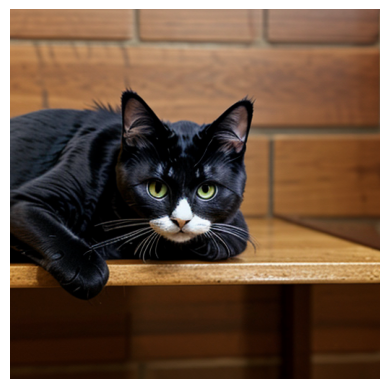

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

cat_path = "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/cat"

img_name = os.listdir(cat_path)[0]
img_path = os.path.join(cat_path, img_name)

img = mpimg.imread(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [10]:
print(img.shape)

(512, 512, 3)


(256, 256, 3)


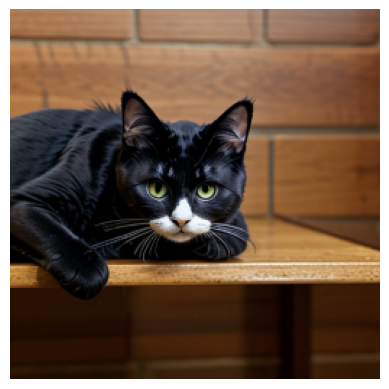

In [11]:
import cv2

resized_img = cv2.resize(img, (256, 256))

print(resized_img.shape)

plt.imshow(resized_img)
plt.axis("off")
plt.show()

In [1]:
import cv2
import os
import numpy as np

X = []
y = []

cat_path = "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/cat"
dog_path = "/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog"

# Cat Images
for img_name in os.listdir(cat_path):
    img = cv2.imread(os.path.join(cat_path, img_name))
    img = cv2.resize(img, (256, 256))
    X.append(img)
    y.append(0)

# Dog Images
for img_name in os.listdir(dog_path):
    img = cv2.imread(os.path.join(dog_path, img_name))
    img = cv2.resize(img, (256, 256))
    X.append(img)
    y.append(1)

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1000, 256, 256, 3)
y Shape: (1000,)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (800, 256, 256, 3)
Testing Images: (200, 256, 256, 3)


In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.min(), X_train.max())
print(X_test.min(), X_test.max())

0.0 1.0
0.0 1.0


In [7]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [8]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-26 07:16:25.923325: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,509,697 (120.20 MB)

 Trainable params: 31,509,697 (120.20 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.6187 - loss: 2.6145 - val_accuracy: 0.6800 - val_loss: 0.6267
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8087 - loss: 0.4619 - val_accuracy: 0.7400 - val_loss: 0.5007
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9062 - loss: 0.2477 - val_accuracy: 0.8950 - val_loss: 0.2723
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9675 - loss: 0.1058 - val_accuracy: 0.9050 - val_loss: 0.2597
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9912 - loss: 0.0386 - val_accuracy: 0.9300 - val_loss: 0.2006
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 0.8950 - val_loss: 0.2766
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.9200 - val_loss: 0.2567
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.9100 - val_loss:

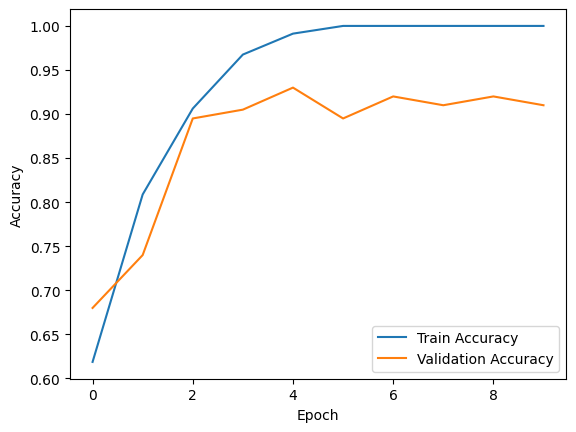

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

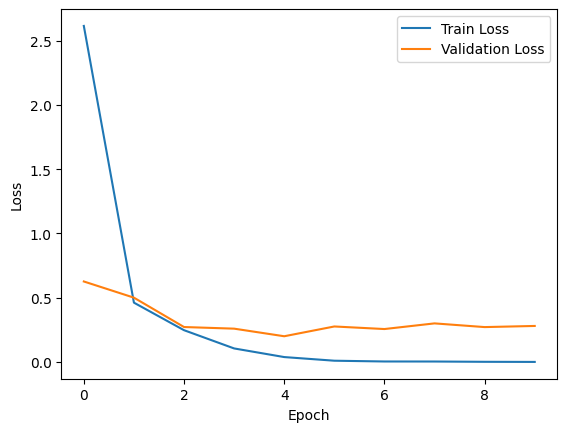

In [18]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [19]:
model.save("cat_dog_cnn.keras")

In [20]:
import os

os.listdir("/kaggle/working")

['cat_dog_cnn.keras', '.virtual_documents']

In [26]:
# 'EXACT_FOLDER_NAME' ko apne Output me aaye naam se replace karein
folder_name = os.listdir("/kaggle/input")[0] 
print(f"Dataset Folder Name: {folder_name}")

# Folder ke andar ki files:
print("Inside files:", os.listdir(f"/kaggle/input/{folder_name}"))

Dataset Folder Name: datasets
Inside files: ['shubhangigupta20', 'anthonytherrien']


In [27]:
import os

path = "/kaggle/input/datasets/shubhangigupta20/test-image"
print(os.listdir(path))

['pezibear-maltese-1123016.jpg']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


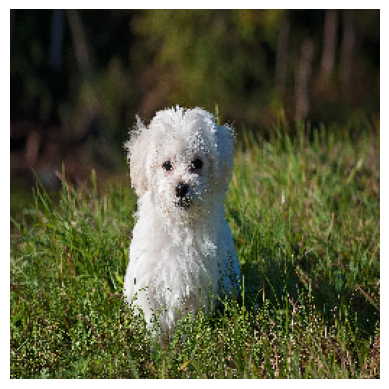

Prediction: Dog 🐶


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# 1. Saved model load karein
model = load_model("cat_dog_cnn.keras")

# 2. Image path
img_path = "/kaggle/input/datasets/shubhangigupta20/test-image/pezibear-maltese-1123016.jpg"

# 3. Image preprocess (256x256 target size)
img = image.load_img(img_path, target_size=(256, 256))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# 4. Predict
prediction = model.predict(img_array)

# 5. Result Display
plt.imshow(img)
plt.axis('off')
plt.show()

if prediction[0][0] > 0.5:
    print("Prediction: Dog 🐶")
else:
    print("Prediction: Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


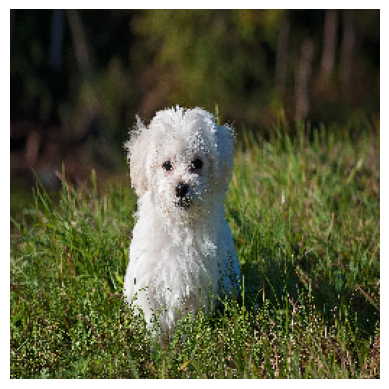

Prediction: Dog 🐶


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# 1. Saved model load karein
model = load_model("cat_dog_cnn.keras")

# 2. Test Image Path
img_path = "/kaggle/input/datasets/shubhangigupta20/test-image/pezibear-maltese-1123016.jpg"

# 3. Image ko 256x256 target size par preprocess karein
img = image.load_img(img_path, target_size=(256, 256))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# 4. Model Prediction
prediction = model.predict(img_array)

# 5. Result Display
plt.imshow(img)
plt.axis('off')
plt.show()

if prediction[0][0] > 0.5:
    print("Prediction: Dog 🐶")
else:
    print("Prediction: Cat 🐱")